Breakdown time seems so long. Let's plot a long one.

In [1]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
%load_ext watermark
%watermark -v -p pandas,matplotlib,numpy

CPython 3.7.7
IPython 7.16.1

pandas 1.0.5
matplotlib 3.2.2
numpy 1.18.5


In [22]:
out_pth_ltf = Path('E:\\','Surfdrive','Screening_Data','out','Figure_LifetimeTraceFittedChem.png')
out_pth_alt = Path('E:\\','Surfdrive','Screening_Data','out','Figure_AllLifetimeTracesChem.png')
out_pth_alt2 = Path('E:\\','Surfdrive','Screening_Data','out','Figure_AllLifetimeTracesChemMean.png')
base_path = Path('E:\\','Surfdrive','Screening_Data_Mutable')
fit = Path(base_path,'2019','11','07','results','D3_fit.csv')
fit = pd.read_csv(fit)
tau = Path(base_path,'2019','11','07','results','D3_tau.csv')
tau = pd.read_csv(tau,'\t',header=None)
frameinterval = 5
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-4 * (x - d)/c)) 

In [3]:
fit_sel = fit[fit['breakdown time(s)'] > 50]
fit_sel = fit_sel[fit_sel['breakdown time(s)'] < 100]
fit_sel = fit_sel[fit_sel['error']==0]
fit_sel = fit_sel[fit_sel['e_breakdown time']<2]
fit_sel.head()

,Unnamed: 0,start(ns),range(ns),breakdown time(s),midpoint(s),start tau(ns),e_start,e_range,e_halftime,e_midpoint,error,condition,e_breakdown time
13,13,3.199619,-0.866173,68.148590,194.136625,2.290054,0.005508,0.006543,NaN,0.513786,0.0,PDE3A,1.782243
82,82,3.172364,-0.862255,57.446433,158.105127,2.258721,0.007480,0.008048,NaN,0.470966,0.0,PDE3A,1.524922
108,108,3.143740,-0.872825,54.425402,200.000000,2.247842,0.005480,0.006673,NaN,0.500714,0.0,PDE3A,1.739363
123,123,3.231588,-0.932433,87.096197,190.291324,2.259876,0.005640,0.006568,NaN,0.497951,0.0,PDE3A,1.699236
139,139,3.221013,-0.893395,67.060496,171.579374,2.304786,0.007275,0.008059,NaN,0.532683,0.0,PDE3A,1.769238


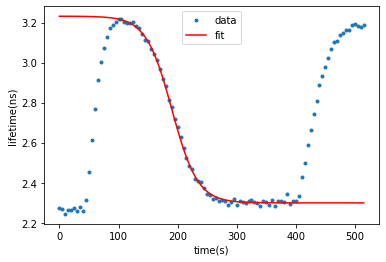

In [4]:
curve_nr = 123;
fig = plt.figure(1)
fit_vals= fit.loc[curve_nr,:]
xax = np.arange(0,frameinterval*len(tau.columns),frameinterval)
y_fit = fit_function(xax,fit_vals['start(ns)'],fit_vals['range(ns)'],fit_vals['breakdown time(s)'],fit_vals['midpoint(s)'])
y_tau = tau.loc[curve_nr,:]
plt.plot(xax,y_tau,'.',xax,y_fit,'r-')
plt.xlabel('time(s)')
plt.ylabel('lifetime(ns)')
plt.legend(['data','fit'])
fig.savefig(out_pth_ltf,dpi=600)

In [5]:
fit_vals

Unnamed: 0                  123
start(ns)               3.23159
range(ns)             -0.932433
breakdown time(s)       87.0962
midpoint(s)             190.291
start tau(ns)           2.25988
e_start              0.00563954
e_range              0.00656819
e_halftime                  NaN
e_midpoint             0.497951
error                         0
condition                 PDE3A
e_breakdown time        1.69924
Name: 123, dtype: object

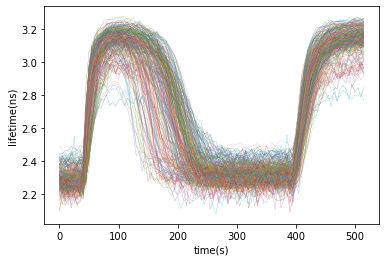

In [8]:
fig = plt.figure(2)
tau_error_free = tau[fit['error']==0]
for i in range(len(tau_error_free)):
    plt.plot(xax,tau_error_free.iloc[i,:],LineWidth=0.2)
plt.xlabel('time(s)')
plt.ylabel('lifetime(ns)')
fig.savefig(out_pth_alt,dpi=600)

In [20]:
tefm = tau_error_free.to_numpy()
tefm = np.mean(tefm,axis=0)

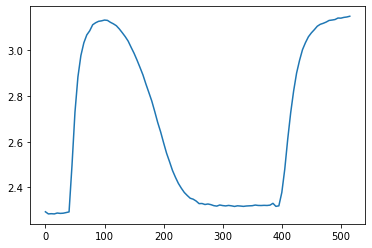

In [21]:
plt.plot(xax,tefm)